<a href="https://colab.research.google.com/github/nilesh426/CSL701-42_Machine-Learning-Lab/blob/main/Experiments/ML_EXP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Nilesh Ashok Sawant
Roll No.: CE42
Batch: CE3

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


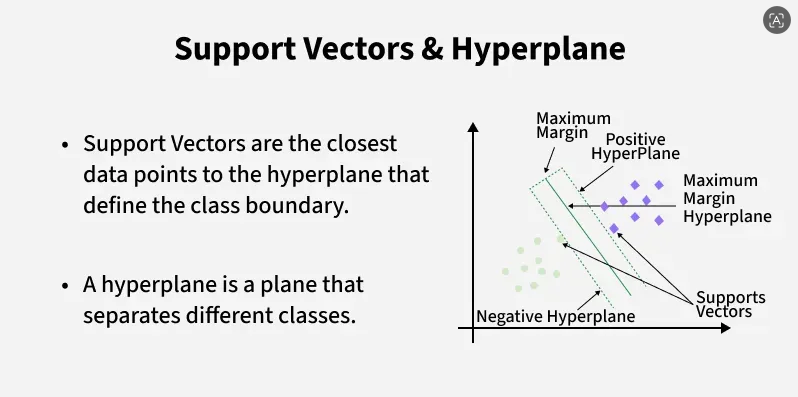
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [15]:
# Task 1: Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Upload CSV file
uploaded = files.upload()


# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(file_name)


# Display file name
print("Selected File:", file_name)

# Display first 5 rows
print("\nFirst 5 Rows of Dataset:")
print(df.head())

Saving Iris (1).csv to Iris (1) (1).csv
Selected File: Iris (1) (1).csv

First 5 Rows of Dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


# Task 2: Explore the Dataset

In [16]:
# Display dataset information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSpecies Count:")
print(df["Species"].value_counts())

Dataset Shape: (150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [17]:
# Remove Id column
df = df.drop("Id", axis=1)

# Select features
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

# Select target
y = df["Species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [18]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [19]:
# Create Linear SVM model
svm_model = SVC(kernel="linear", random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred_svm)

Actual Values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']

Predicted Values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [20]:
# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix:")
print(cm_svm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0
SVM Accuracy (%): 100.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Confusion Matrix Visualization

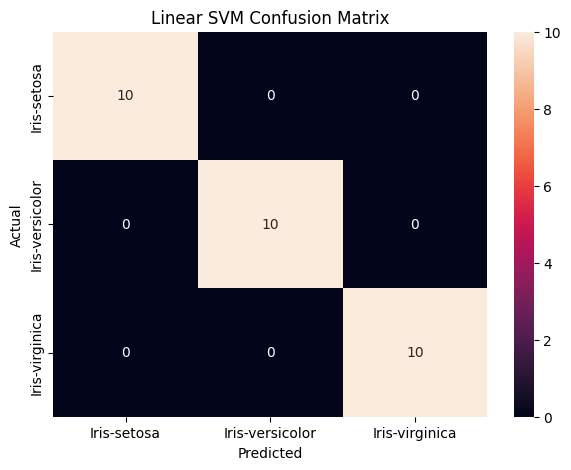

In [21]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

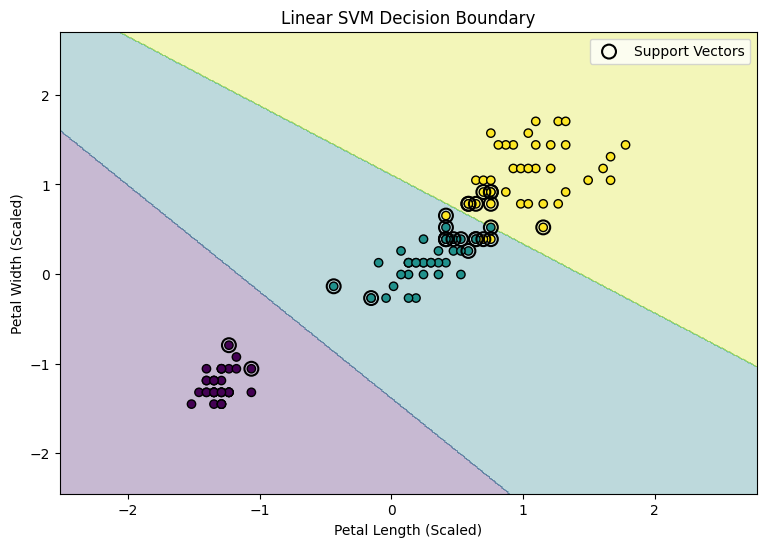

In [22]:
# Select two features for visualization
X_2d = df[
    [
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y_2d = df["Species"]

# Split the 2-D dataset
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Scale the 2-D data
scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train Linear SVM
svm_2d = SVC(kernel="linear", random_state=42)

svm_2d.fit(X_train_2d_scaled, y_train_2d)

# Create mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict each point in the mesh
Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Convert class labels to numbers for contour plotting
class_mapping = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

Z_numeric = np.vectorize(class_mapping.get)(Z)

y_train_numeric = y_train_2d.map(class_mapping)

# Plot decision boundary
plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.3
)

plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_numeric,
    edgecolors="k"
)

# Highlight support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()

plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [23]:
# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train Logistic Regression
logistic_model.fit(
    X_train_2d_scaled,
    y_train_2d
)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_2d_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test_2d,
    y_pred_logistic
)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression Accuracy (%):", logistic_accuracy * 100)

Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Accuracy (%): 93.33333333333333


Plot Logistic Regression Decision Boundary

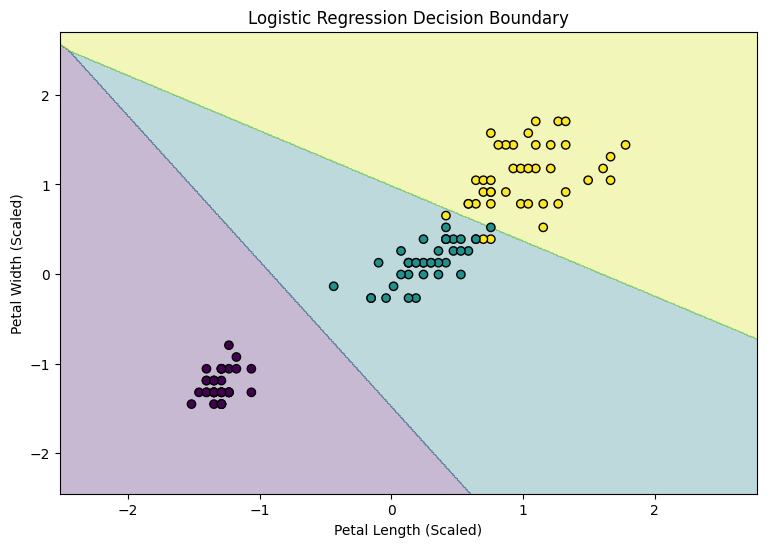

In [24]:
# Predict mesh points
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z_logistic = Z_logistic.reshape(xx.shape)

Z_logistic_numeric = np.vectorize(
    class_mapping.get
)(Z_logistic)

# Plot
plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z_logistic_numeric,
    alpha=0.3
)

plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_numeric,
    edgecolors="k"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")

plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

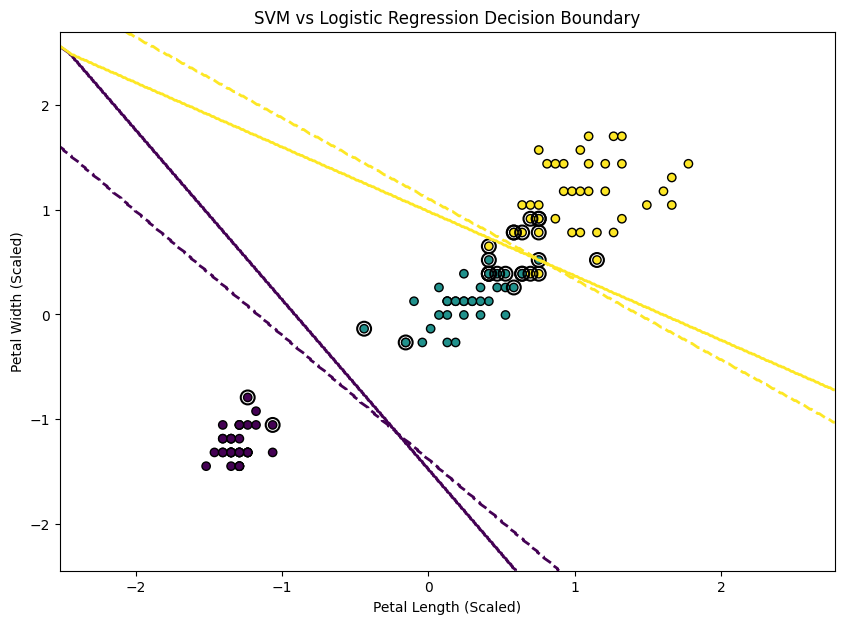

In [25]:
# SVM predictions on mesh
Z_svm = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z_svm = Z_svm.reshape(xx.shape)

Z_svm_numeric = np.vectorize(
    class_mapping.get
)(Z_svm)


# Logistic Regression predictions on mesh
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z_logistic = Z_logistic.reshape(xx.shape)

Z_logistic_numeric = np.vectorize(
    class_mapping.get
)(Z_logistic)


# Create comparison figure
plt.figure(figsize=(10, 7))

# SVM boundary
plt.contour(
    xx,
    yy,
    Z_svm_numeric,
    levels=[0.5, 1.5],
    linestyles="--",
    linewidths=2
)

# Logistic Regression boundary
plt.contour(
    xx,
    yy,
    Z_logistic_numeric,
    levels=[0.5, 1.5],
    linestyles="-",
    linewidths=2
)

# Plot data points
plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_numeric,
    edgecolors="k"
)

# Plot SVM support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="SVM Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("SVM vs Logistic Regression Decision Boundary")

plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [26]:
# ============================
# SVM PERFORMANCE
# ============================

print("=" * 50)
print("LINEAR SVM PERFORMANCE")
print("=" * 50)

svm_accuracy = accuracy_score(
    y_test_2d,
    svm_2d.predict(X_test_2d_scaled)
)

svm_predictions = svm_2d.predict(X_test_2d_scaled)

print("\nAccuracy:")
print(svm_accuracy)

print("\nAccuracy (%):")
print(svm_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_2d,
    svm_predictions
))

print("\nClassification Report:")
print(classification_report(
    y_test_2d,
    svm_predictions
))


# ============================
# LOGISTIC REGRESSION
# ============================

print("\n")
print("=" * 50)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 50)

logistic_predictions = logistic_model.predict(
    X_test_2d_scaled
)

logistic_accuracy = accuracy_score(
    y_test_2d,
    logistic_predictions
)

print("\nAccuracy:")
print(logistic_accuracy)

print("\nAccuracy (%):")
print(logistic_accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_2d,
    logistic_predictions
))

print("\nClassification Report:")
print(classification_report(
    y_test_2d,
    logistic_predictions
))

LINEAR SVM PERFORMANCE

Accuracy:
0.9333333333333333

Accuracy (%):
93.33333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



LOGISTIC REGRESSION PERFORMANCE

Accuracy:
0.9333333333333333

Accuracy (%):
93.33333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy          

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.